In [13]:
%matplotlib widget

# Match pulses between `dfd.csv` and `dfr.csv` with SciPy

This notebook matches visible pulses in **`dfd.csv`** to pulses in **`dfr.csv`**.

Assumptions:

- `dfr.csv` contains all pulses
- `dfd.csv` is missing some pulses in some regions
- the **first** visible pulse in `dfd` matches the **first** visible pulse in `dfr`
- the **last** visible pulse in `dfd` matches the **last** visible pulse in `dfr`

The output table puts the matching values from both files on the **same row**, including:

- `dfd_Time`
- `dfr_Time`
- `dfd_ch0zcomplete`
- `dfr_ch0zcomplete`
- matching error in microseconds


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from scipy.interpolate import interp1d

## 1) Load the CSV files

Put `dfd.csv` and `dfr.csv` in the same folder as this notebook, or change the paths below.


In [2]:
dfr = pd.read_csv("Output_Factor_6FFF_reference_air_scan_10x10_6x_crossline_dmax_5mm-s_2026-04-19_15-01-39.csv", skiprows=33)
dfd = pd.read_csv("6FFF_detector_scan_air_10x10_6x_crossline_dmax_5mm-s_10.0x10.0_Profile_X_Depth-14.0_continuous_Speed-25.0_2026-04-19_15-01-45.csv", skiprows=43)

print("dfr shape:", dfr.shape)
print("dfd shape:", dfd.shape)
print(dfr.columns.tolist())

dfr shape: (93544, 3)
dfd shape: (74747, 3)
['Time', 'single_pulse', 'ch0zcomplete']


## 2) Keep only the rows where a pulse is visible

This notebook expects:

- a time column called `Time`
- a pulse flag called `single_pulse`
- a signal column called `ch0zcomplete`

Change those names below if your columns use different names.


In [3]:
time_col = "Time"
pulse_col = "single_pulse"
signal_col = "ch0zcomplete"

pr = (
    dfr.loc[dfr[pulse_col]].copy()
       .reset_index()
       .rename(columns={"index": "dfr_row"})
       .sort_values(time_col)
       .reset_index(drop=True)
)

pd_ = (
    dfd.loc[dfd[pulse_col]].copy()
       .reset_index()
       .rename(columns={"index": "dfd_row"})
       .sort_values(time_col)
       .reset_index(drop=True)
)

print("Visible pulses in dfr:", len(pr))
print("Visible pulses in dfd:", len(pd_))

display(pr[[time_col, signal_col]].head())
display(pd_[[time_col, signal_col]].head())

Visible pulses in dfr: 15280
Visible pulses in dfd: 9134


,Time,ch0zcomplete
0,22.908356,2.456291
1,22.910683,2.379096
2,22.913786,2.299917
3,22.916885,4.508935
4,22.919213,4.141986


,Time,ch0zcomplete
0,4.793416,1.094470
1,4.795775,1.028220
2,4.798928,1.032595
3,4.801289,2.009783
4,4.804438,2.022908


## 3) Build a time mapping from `dfd` to `dfr`

We use the first and last pulse as anchors, then linearly map `dfd` time to the `dfr` time axis.


In [4]:
t_r0 = pr[time_col].iloc[0]
t_r1 = pr[time_col].iloc[-1]
t_d0 = pd_[time_col].iloc[0]
t_d1 = pd_[time_col].iloc[-1]

scale = (t_r1 - t_r0) / (t_d1 - t_d0)
offset = t_r0 - scale * t_d0

pd_["Time_mapped"] = pd_[time_col] * scale + offset

print(f"scale  = {scale}")
print(f"offset = {offset}")

scale  = 0.9976940197866307
offset = 18.12599352245045


## 4) Use SciPy `cKDTree` to find the nearest pulse in `dfr`

We build a 1D nearest-neighbor search on `dfr` pulse times, then query it with the mapped `dfd` times.


In [5]:
r_times = pr[time_col].to_numpy()
d_times_mapped = pd_["Time_mapped"].to_numpy()

tree = cKDTree(r_times.reshape(-1, 1))
dist_s, idx = tree.query(d_times_mapped.reshape(-1, 1), k=1)

pd_["matched_idx_in_pr"] = idx
pd_["matched_dfr_row"] = pr.iloc[idx]["dfr_row"].to_numpy()
pd_["dfr_Time"] = pr.iloc[idx][time_col].to_numpy()
pd_["dfr_ch0zcomplete"] = pr.iloc[idx][signal_col].to_numpy()

pd_["match_error_s"] = pd_["dfr_Time"] - pd_["Time_mapped"]
pd_["match_error_us"] = pd_["match_error_s"] * 1e6
pd_["abs_err_us"] = np.abs(pd_["match_error_us"])

display(pd_[[time_col, "Time_mapped", "dfr_Time", "match_error_us"]].head())

,Time,Time_mapped,dfr_Time,match_error_us
0,4.793416,22.908356,22.908356,0.000000
1,4.795775,22.910710,22.910683,-26.560193
2,4.798928,22.913855,22.913786,-69.289437
3,4.801289,22.916211,22.916885,674.154982
4,4.804438,22.919353,22.919213,-139.583486


## 5) Optional tolerance filter

Set a maximum allowed time error in microseconds.
Use `None` to disable.


In [6]:
max_error_us = None   # example: 200

matches = pd_.copy()

if max_error_us is not None:
    matches = matches.loc[matches["abs_err_us"] <= max_error_us].copy()

print("Rows after tolerance filter:", len(matches))

Rows after tolerance filter: 9134


## 6) Remove duplicate matches

Sometimes two `dfd` pulses can point to the same `dfr` pulse.
We keep the one with the smallest absolute timing error.


In [7]:
matches = (
    matches.sort_values("abs_err_us")
           .drop_duplicates(subset="matched_dfr_row", keep="first")
           .sort_values("dfd_row")
           .reset_index(drop=True)
)

print("Rows after duplicate removal:", len(matches))

Rows after duplicate removal: 9096


## 7) Enforce monotonic matching

Because pulse order should be preserved, the matched `dfr` row numbers should increase.


In [8]:
keep = []
last = -np.inf

for row in matches["matched_dfr_row"].to_numpy():
    ok = row > last
    keep.append(ok)
    if ok:
        last = row

matches = matches.loc[keep].reset_index(drop=True)

print("Rows after monotonic filter:", len(matches))

Rows after monotonic filter: 9096


## 8) Final matched table

Each row is one matched pulse pair.


In [9]:
matched_pulses = matches[[
    "dfd_row",
    "matched_dfr_row",
    time_col,
    "dfr_Time",
    signal_col,
    "dfr_ch0zcomplete",
    "match_error_us",
]].rename(columns={
    time_col: "dfd_Time",
    signal_col: "dfd_ch0zcomplete",
})

display(matched_pulses.head())
print(matched_pulses.shape)

,dfd_row,matched_dfr_row,dfd_Time,dfr_Time,dfd_ch0zcomplete,dfr_ch0zcomplete,match_error_us
0,6077,29534,4.793416,22.908356,1.094470,2.456291,0.000000
1,6080,29537,4.795775,22.910683,1.028220,2.379096,-26.560193
2,6084,29541,4.798928,22.913786,1.032595,2.299917,-69.289437
3,6087,29545,4.801289,22.916885,2.009783,4.508935,674.154982
4,6091,29548,4.804438,22.919213,2.022908,4.141986,-139.583486


(9096, 7)


## 9) Save the matched table to CSV

In [10]:
matched_pulses.to_csv("matched_pulses_scipy.csv", index=False)
print("Saved: matched_pulses_scipy.csv")

Saved: matched_pulses_scipy.csv


## 10) Write reference columns back into the original `dfd`

This is useful if you want the original dataframe plus the corresponding values from `dfr`.


In [11]:
dfd_out = dfd.copy()

dfd_out["dfr_row_reference"] = pd.NA
dfd_out["dfr_time_reference"] = np.nan
dfd_out["dfr_ch0zcomplete_reference"] = np.nan
dfd_out["match_error_us"] = np.nan

dfd_out.loc[matched_pulses["dfd_row"], "dfr_row_reference"] = matched_pulses["matched_dfr_row"].to_numpy()
dfd_out.loc[matched_pulses["dfd_row"], "dfr_time_reference"] = matched_pulses["dfr_Time"].to_numpy()
dfd_out.loc[matched_pulses["dfd_row"], "dfr_ch0zcomplete_reference"] = matched_pulses["dfr_ch0zcomplete"].to_numpy()
dfd_out.loc[matched_pulses["dfd_row"], "match_error_us"] = matched_pulses["match_error_us"].to_numpy()

dfd_out.to_csv("dfd_with_references_scipy.csv", index=False)
print("Saved: dfd_with_references_scipy.csv")

display(dfd_out.head())

Saved: dfd_with_references_scipy.csv


,Time,single_pulse,ch0zcomplete,dfr_row_reference,dfr_time_reference,dfr_ch0zcomplete_reference,match_error_us
0,0.009438,False,0.017908,<NA>,NaN,NaN,NaN
1,0.010224,False,0.045095,<NA>,NaN,NaN,NaN
2,0.011009,False,-0.073030,<NA>,NaN,NaN,NaN
3,0.011795,False,-0.037717,<NA>,NaN,NaN,NaN
4,0.012582,False,-0.053030,<NA>,NaN,NaN,NaN


## 11) Quick visual check

Blue = all pulses from `dfr`  
Orange = pulses from `dfd`, placed at their matched `dfr` times


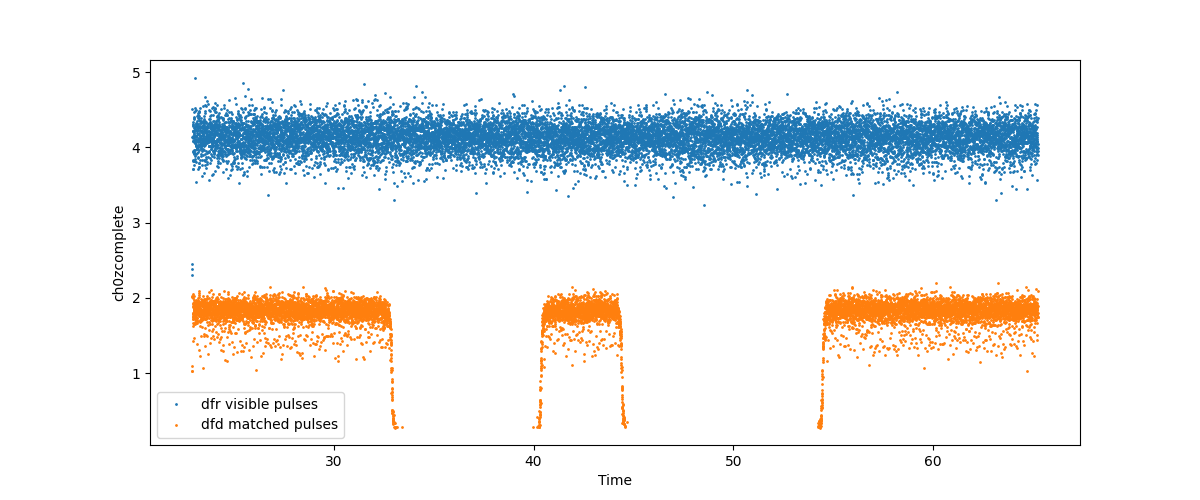

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(pr[time_col], pr[signal_col], ".", ms=2, label="dfr visible pulses")
plt.plot(matched_pulses["dfr_Time"], matched_pulses["dfd_ch0zcomplete"], ".", ms=2, label="dfd matched pulses")
plt.xlabel("Time")
plt.ylabel("ch0zcomplete")
plt.legend()
plt.show()

## 12) Optional improvement: non-linear drift correction with SciPy interpolation

If you notice that the timing drift is not perfectly linear, you can estimate a smooth index-based mapping
between `dfd` pulse number and `dfr` pulse number using the matched pairs from the first pass.

This cell builds an interpolated pulse-index mapping that you can use for a second-pass match.


In [ ]:
# Build an index-to-index interpolator from current matches
x_idx = np.arange(len(matches))
y_idx = matches["matched_idx_in_pr"].to_numpy()

interp_idx = interp1d(
    x_idx,
    y_idx,
    kind="linear",
    fill_value="extrapolate",
    bounds_error=False,
)

# Predicted dfr pulse index for every dfd pulse
pred_idx = interp_idx(np.arange(len(pd_)))
pred_idx = np.clip(pred_idx, 0, len(pr) - 1)

# Convert predicted indices to predicted times
pred_times = np.interp(pred_idx, np.arange(len(pr)), pr[time_col].to_numpy())

plt.figure(figsize=(12, 4))
plt.plot(pd_[time_col], pd_["Time_mapped"], ".", ms=2, label="linear mapped time")
plt.plot(pd_[time_col], pred_times, ".", ms=2, label="interpolated predicted dfr time")
plt.xlabel("Original dfd Time")
plt.ylabel("Predicted dfr Time")
plt.legend()
plt.show()